In [1]:
# Shoreward fluxes from aligned data
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import cm


In [2]:
out_dir = 'F:/crs/proj/2025_NOPP_comparison/helene_contour_all3/'
ds_hw = xr.open_dataset(out_dir + "hurrywave_aligned.nc")
ds_ad = xr.open_dataset(out_dir + "adcirc_aligned.nc")
ds_cw = xr.open_dataset(out_dir + "coawst_aligned.nc")

In [3]:
def add_energy_fluxes(ds, rho=1025.0, g=9.81):
    """
    Add wave-energy flux variables to a harmonized dataset.

    Requires:
      spec(time, point, freq, dir)   in m^2/Hz/rad
      freq(freq)                     in Hz
      dir(dir)                       in degrees FROM
      normal_x(point), normal_y(point)   optional for fshore

    Adds:
      fx(time, point)       eastward flux (W/m)
      fy(time, point)       northward flux (W/m)
      fmag(time, point)     flux magnitude (W/m)
      ftoward(time, point)  flux direction TOWARD, deg clockwise from north
      fshore(time, point)   shoreward flux (W/m), if normals exist
    """
    f = ds["freq"].values
    dir_from = ds["dir"].values
    theta_tow = np.deg2rad((dir_from + 180.0) % 360.0)   # convert FROM -> TOWARD

    S = ds["spec"].values                                 # (time, point, freq, dir)

    dtheta = np.abs(theta_tow[1] - theta_tow[0])
    cg = g / (4.0 * np.pi * f)                            # deep-water group velocity
    wfreq = rho * g * cg                                  # frequency weight for flux

    ex = np.sin(theta_tow)                                # east component
    ny = np.cos(theta_tow)                                # north component

    # integrate over direction first -> (time, point, freq)
    Sfx_f = np.sum(S * ex[np.newaxis, np.newaxis, np.newaxis, :], axis=-1) * dtheta
    Sfy_f = np.sum(S * ny[np.newaxis, np.newaxis, np.newaxis, :], axis=-1) * dtheta

    # integrate over frequency -> (time, point)
    fx = np.trapezoid(Sfx_f * wfreq[np.newaxis, np.newaxis, :], f, axis=-1)
    fy = np.trapezoid(Sfy_f * wfreq[np.newaxis, np.newaxis, :], f, axis=-1)

    fmag = np.sqrt(fx**2 + fy**2)
    ftoward = (np.rad2deg(np.arctan2(fx, fy)) + 360.0) % 360.0

    ds["fx"] = (("time", "point"), fx)
    ds["fy"] = (("time", "point"), fy)
    ds["fmag"] = (("time", "point"), fmag)
    ds["ftoward"] = (("time", "point"), ftoward)

    ds["fx"].attrs["units"] = "W/m"
    ds["fy"].attrs["units"] = "W/m"
    ds["fmag"].attrs["units"] = "W/m"
    ds["ftoward"].attrs["units"] = "degrees"

    if "normal_x" in ds and "normal_y" in ds:
        nx = ds["normal_x"].values
        nyv = ds["normal_y"].values
        fshore = (fx * nx[np.newaxis, :]) + fy * nyv[np.newaxis, :]
        ds["fshore"] = (("time", "point"), fshore)
        ds["fshore"].attrs["units"] = "W/m"

    return ds

In [4]:
ds_hw = add_energy_fluxes(ds_hw)
ds_ad = add_energy_fluxes(ds_ad)
ds_cw = add_energy_fluxes(ds_cw)

3431.0073587308257
3500.265334550905
2588.748023872386


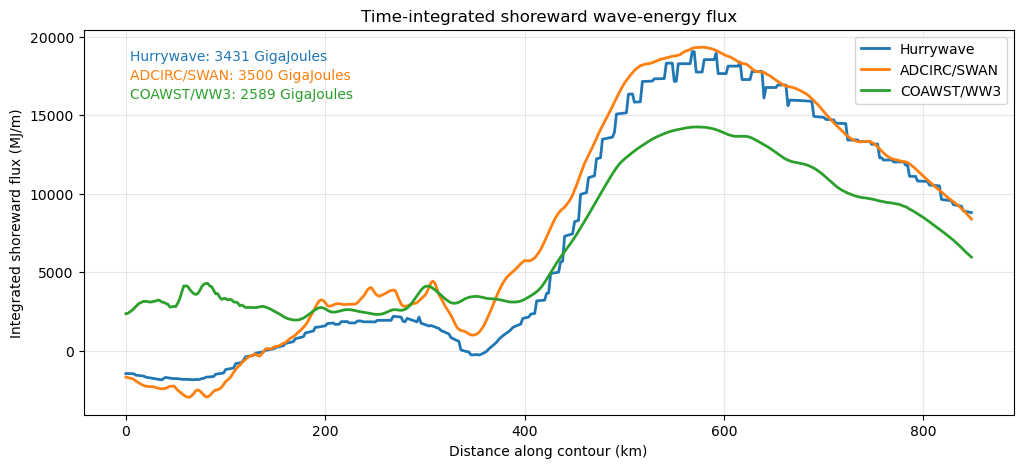

In [5]:
def cumulative_distance(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)
    return np.concatenate(([0.0], np.cumsum(ds)))

def integrate_fshore_over_time(ds):
    """
    Integrate shoreward flux over time at each contour point.

    Requires:
      ds["fshore"] with dims (time, point), units W/m
      ds["time"]   datetime64 array

    Returns:
      fint(point) in J/m
    """
    time = ds["time"].values
    tsec = (time - time[0]) / np.timedelta64(1, "s")
    fint = np.trapezoid(ds["fshore"].values, tsec, axis=0)
    return fint

# distance along contour (km)
s = cumulative_distance(ds_hw["x"].values, ds_hw["y"].values) / 1000.0

# integrate over time
fint_hw = integrate_fshore_over_time(ds_hw)
fint_ad = integrate_fshore_over_time(ds_ad)
fint_cw = integrate_fshore_over_time(ds_cw)

# and over distance along the contour, starting with point i0, removing negative values first
i0 = 300
fint_hw_pos = np.maximum(fint_hw, 0.0)
total_hw = np.trapezoid(fint_hw_pos[i0:], s[i0:])/1.e9 # billion joules = GigaJoules
fint_ad_pos = np.maximum(fint_ad, 0.0)
total_ad = np.trapezoid(fint_ad_pos[i0:], s[i0:])/1.e9 # billion joules = GigaJoules
fint_cw_pos = np.maximum(fint_cw, 0.0)
total_cw = np.trapezoid(fint_cw_pos[i0:], s[i0:])/1.e9 # billion joules = GigaJoules

print(total_hw)
print(total_ad)
print(total_cw)

# plot in MJ/m
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(s, fint_hw / 1e6, lw=2, label="Hurrywave")
ax.plot(s, fint_ad / 1e6, lw=2, label="ADCIRC/SWAN")
ax.plot(s, fint_cw / 1e6, lw=2, label="COAWST/WW3")

ax.text(0.05, 0.95, f"Hurrywave: {total_hw:.0f} GigaJoules", transform=ax.transAxes, ha='left', va='top', color = 'tab:blue')
ax.text(0.05, 0.90, f"ADCIRC/SWAN: {total_ad:.0f} GigaJoules", transform=ax.transAxes, ha='left', va='top', color = 'tab:orange')
ax.text(0.05, 0.85, f"COAWST/WW3: {total_cw:.0f} GigaJoules", transform=ax.transAxes, ha='left', va='top', color = 'tab:green')


ax.set_xlabel("Distance along contour (km)")
ax.set_ylabel("Integrated shoreward flux (MJ/m)")
ax.set_title("Time-integrated shoreward wave-energy flux")
ax.grid(True, alpha=0.3)
ax.legend()
plt.savefig('integ_shoreward_flux.png')
plt.show()

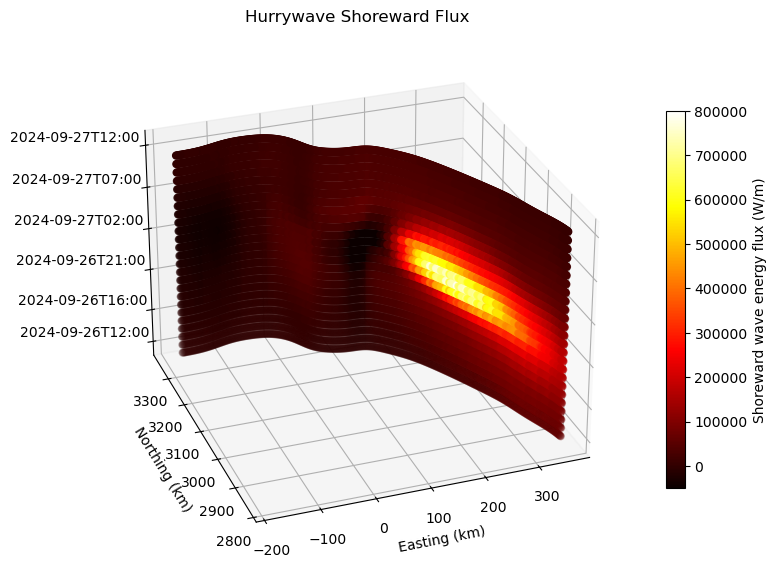

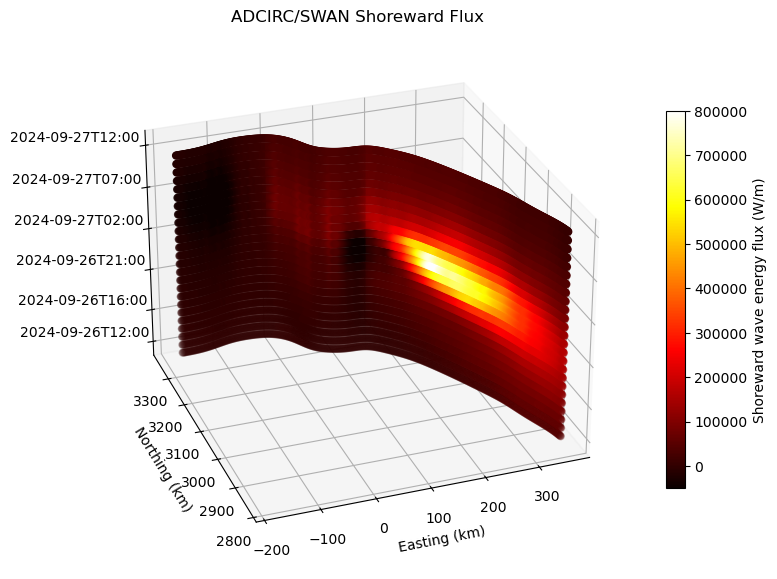

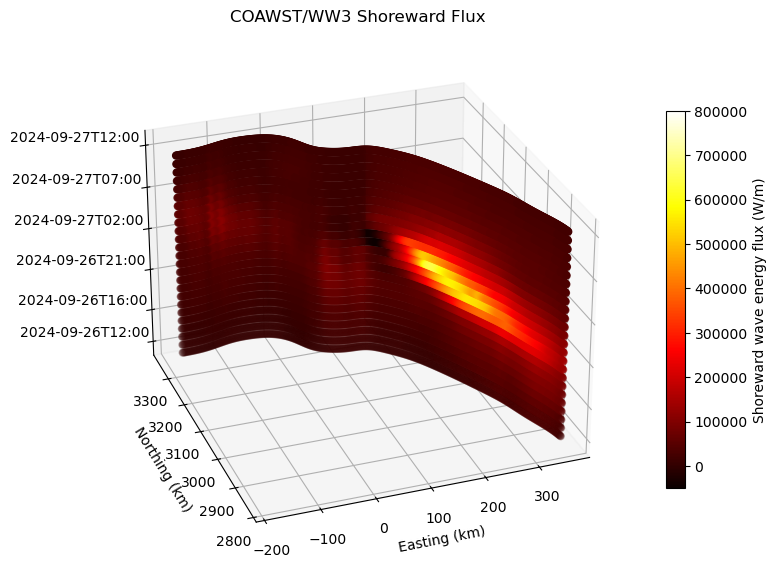

In [6]:
def plot_curtain_fshore(ds, title=None, scale_km=True, cmap=cm.hot, 
                        t0=None, t1=None, point_stride=1,
                        elev=28, azim=250, ztick_pad=26,
                        vmin=None, vmax=None, fig_name_base='unknown'):
    """
    3D curtain plot with controlled color range.
    """

    if t0 is not None or t1 is not None:
        ds = ds.sel(time=slice(t0, t1))

    x = ds["x"].values
    y = ds["y"].values
    time = ds["time"].values
    fshore = ds["fshore"].values

    if point_stride > 1:
        x = x[::point_stride]
        y = y[::point_stride]
        fshore = fshore[:, ::point_stride]

    if scale_km:
        xplot = x / 1000.0
        yplot = y / 1000.0
        xlabel = "Easting (km)"
        ylabel = "Northing (km)"
    else:
        xplot = x
        yplot = y
        xlabel = "Easting (m)"
        ylabel = "Northing (m)"

    nt, npnt = fshore.shape

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # ---- FIXED COLOR RANGE ----
    if vmin is None:
        vmin = np.nanmin(fshore)
    if vmax is None:
        vmax = np.nanmax(fshore)

    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for i in range(npnt):
        xx = np.full(nt, xplot[i])
        yy = np.full(nt, yplot[i])
        zz = np.arange(nt)

        sc = ax.scatter(xx, yy, zz, c=fshore[:, i],
                        cmap=cmap, norm=norm, s=25)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    iz = np.linspace(0, nt - 1, 6).astype(int)
    ax.set_zticks(iz)
    ax.set_zticklabels([str(time[i])[:16] for i in iz])
    ax.zaxis.set_tick_params(pad=ztick_pad)

    ax.view_init(elev=elev, azim=azim)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label("Shoreward wave energy flux (W/m)")

    if title is None:
        title = ds.attrs.get("model", "Model")
    ax.set_title(title)
    plt.savefig(fig_name_base+"_flux_curtain.png")
    plt.show()
    
t0 = "2024-09-26T12:00"
t1 = "2024-09-27T12:00"
plot_curtain_fshore(ds_hw, t0=t0, t1=t1, point_stride=1, vmin=-50000, vmax = 800000, title="Hurrywave Shoreward Flux",fig_name_base='hurrywave')
plot_curtain_fshore(ds_ad, t0=t0, t1=t1, point_stride=1, vmin=-50000, vmax = 800000,title="ADCIRC/SWAN Shoreward Flux",fig_name_base='adcirc_swan')
plot_curtain_fshore(ds_cw, t0=t0, t1=t1, point_stride=1, vmin=-50000, vmax = 800000,title="COAWST/WW3 Shoreward Flux",fig_name_base='coawst_ww3')

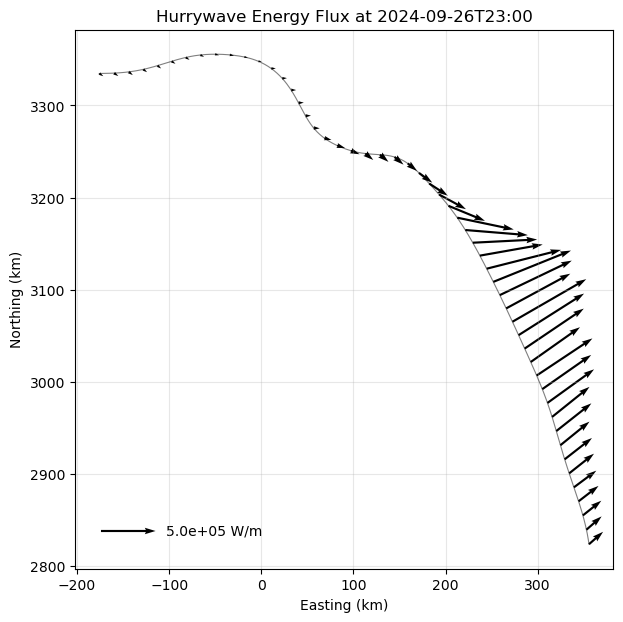

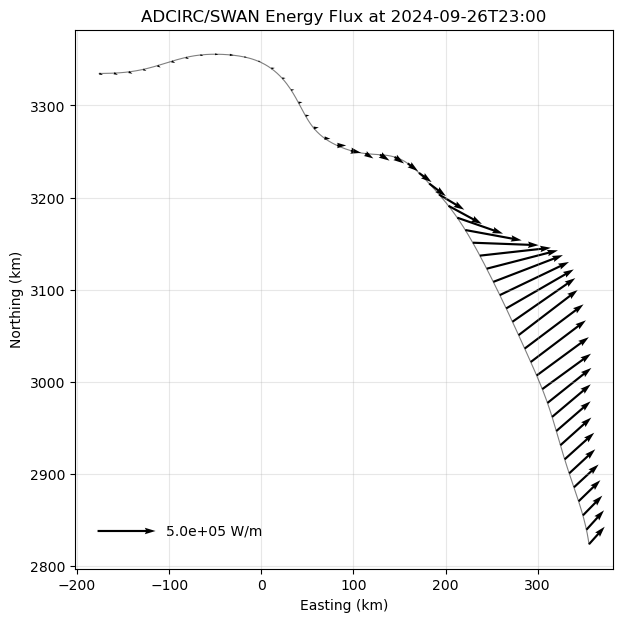

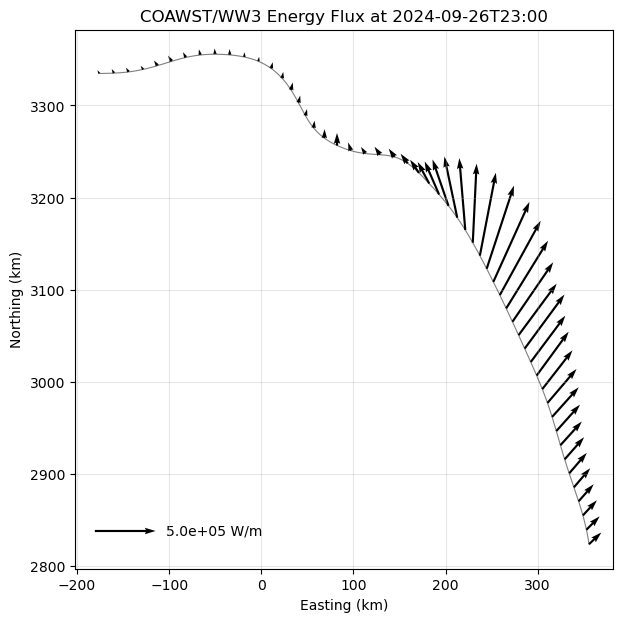

In [7]:
def get_time_of_max_mean_fshore(ds):
    ts = ds["fshore"].mean(dim="point").values
    it = int(np.nanargmax(ts))
    return it, ds["time"].values[it]


def get_nearest_time_index(ds, tsel):
    tsel = np.datetime64(tsel)
    time = ds["time"].values
    it = np.argmin(np.abs(time - tsel))
    return int(it)


def plot_flux_vectors(ds, it=None, tsel=None, stride=5, scale_km=True, title=None, fig_name_base=None):
    """
    2D quiver plot of flux vectors at one time.
    """
    if tsel is not None:
        it = get_nearest_time_index(ds, tsel)
    elif it is None:
        it, _ = get_time_of_max_mean_fshore(ds)

    x = ds["x"].values
    y = ds["y"].values
    fx = ds["fx"].isel(time=it).values
    fy = ds["fy"].isel(time=it).values
    t = ds["time"].values[it]

    ii = np.arange(0, len(x), stride)

    if scale_km:
        xplot = x[ii] / 1000.0
        yplot = y[ii] / 1000.0
        xlabel = "Easting (km)"
        ylabel = "Northing (km)"
        xline = x / 1000.0
        yline = y / 1000.0
    else:
        xplot = x[ii]
        yplot = y[ii]
        xlabel = "Easting (m)"
        ylabel = "Northing (m)"
        xline = x
        yline = y

    fig, ax = plt.subplots(figsize=(9, 7))

    q1 = ax.quiver(
        xplot, yplot,
        -fx[ii], -fy[ii],
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.004
    )

    # ---- Reference arrow ----
    ax.quiverkey(
        q1,
        X=0.15, Y=0.07,          # lower left
        U=5e5,
        label=f"{5e5:.1e} W/m",
        labelpos="E",
        coordinates="axes"
    )

    ax.plot(xline, yline, "k-", lw=0.8, alpha=0.5)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    if title is None:
        title = ds.attrs.get("model", "Model")
    ax.set_title(f"{title} Energy Flux at {str(t)[:16]}")
    plt.savefig(fig_name_base+'energy_flux_vector_plot.png')
    plt.show()
    
plot_flux_vectors(ds_hw, stride=8, tsel="2024-09-26T23:00", title="Hurrywave", fig_name_base='hurrywave')
plot_flux_vectors(ds_ad, stride=8, tsel="2024-09-26T23:00", title="ADCIRC/SWAN", fig_name_base='adcirc_swan')
plot_flux_vectors(ds_cw, stride=8, tsel="2024-09-26T23:00", title="COAWST/WW3", fig_name_base='coawst_ww3')

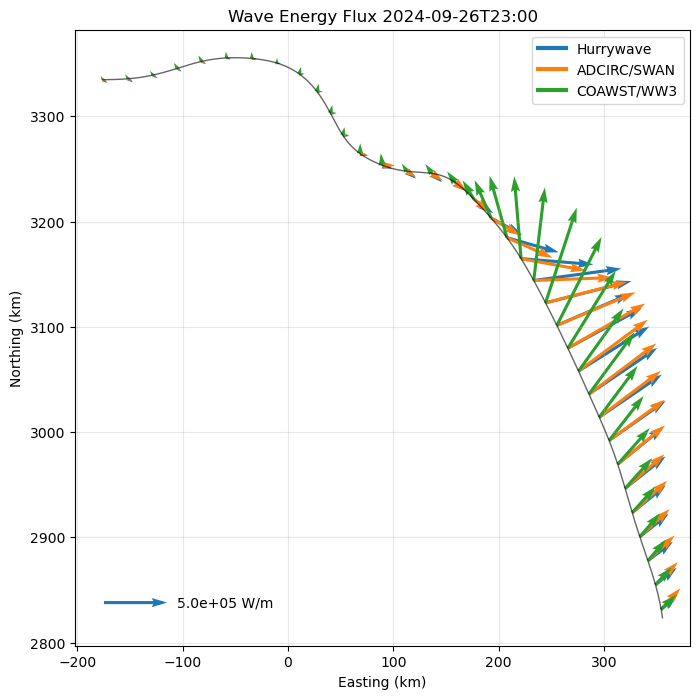

In [8]:
def get_nearest_time_index(ds, tsel):
    tsel = np.datetime64(tsel)
    time = ds["time"].values
    return int(np.argmin(np.abs(time - tsel)))

def plot_flux_vectors_overlay(ds1, ds2, ds3,
                              labels=("Hurrywave", "ADCIRC/SWAN", "COAWST/WW3"),
                              colors = ('tab:blue', 'tab:orange','tab:green'),
                              it=None, tsel=None, stride=8, scale_km=True,
                              title=None, scale=None, ref=None):
    """
    Overlay flux vectors with reference arrow.

    scale : passed to quiver (controls arrow size)
    ref   : reference vector magnitude for legend arrow (W/m)
    """

    if tsel is not None:
        it1 = get_nearest_time_index(ds1, tsel)
        it2 = get_nearest_time_index(ds2, tsel)
        it3 = get_nearest_time_index(ds3, tsel)
    elif it is not None:
        it1 = it2 = it3 = it
    else:
        ts = ds3["fshore"].mean(dim="point").values
        it3 = int(np.nanargmax(ts))
        tsel = ds3["time"].values[it3]
        it1 = get_nearest_time_index(ds1, tsel)
        it2 = get_nearest_time_index(ds2, tsel)

    x = ds1["x"].values
    y = ds1["y"].values
    ii = np.arange(0, len(x), stride)

    if scale_km:
        xline = x / 1000.0
        yline = y / 1000.0
        xplot = x[ii] / 1000.0
        yplot = y[ii] / 1000.0
        xlabel = "Easting (km)"
        ylabel = "Northing (km)"
    else:
        xline = x
        yline = y
        xplot = x[ii]
        yplot = y[ii]
        xlabel = "Easting (m)"
        ylabel = "Northing (m)"

    fx1 = ds1["fx"].isel(time=it1).values[ii]
    fy1 = ds1["fy"].isel(time=it1).values[ii]

    fx2 = ds2["fx"].isel(time=it2).values[ii]
    fy2 = ds2["fy"].isel(time=it2).values[ii]

    fx3 = ds3["fx"].isel(time=it3).values[ii]
    fy3 = ds3["fy"].isel(time=it3).values[ii]

    t1 = ds1["time"].values[it1]

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.plot(xline, yline, "k-", lw=1.0, alpha=0.6)

    q1 = ax.quiver(xplot, yplot, -fx1, -fy1, color=colors[0],
                   angles="xy", scale_units="xy", scale=scale, width=0.005)
    q2 = ax.quiver(xplot, yplot, -fx2, -fy2, color=colors[1],
                   angles="xy", scale_units="xy", scale=scale, width=0.005)
    q3 = ax.quiver(xplot, yplot, -fx3, -fy3, color=colors[2],
                   angles="xy", scale_units="xy", scale=scale, width=0.005)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    if title is None:
        title = "Wave energy flux vectors"

    ax.set_title(f"{title} {str(t1)[:16]}")

    # ---- Reference arrow ----
    if ref is None:
        # choose something representative automatically
        ref = 5e5   # adjust after first look if needed

    ax.quiverkey(
        q1,
        X=0.15, Y=0.07,          # lower left
        U=ref,
        label=f"{ref:.1e} W/m",
        labelpos="E",
        coordinates="axes"
    )

    # legend for models
    handles = [
        plt.Line2D([0],[0], color=colors[0], lw=3),
        plt.Line2D([0],[0], color=colors[1], lw=3),
        plt.Line2D([0],[0], color=colors[2], lw=3),
    ]
    ax.legend(handles, labels, loc="upper right")

    plt.show()

plot_flux_vectors_overlay(
    ds_hw, ds_ad, ds_cw,
    tsel="2024-09-26T23:00",
    stride=12,
    title="Wave Energy Flux"
)

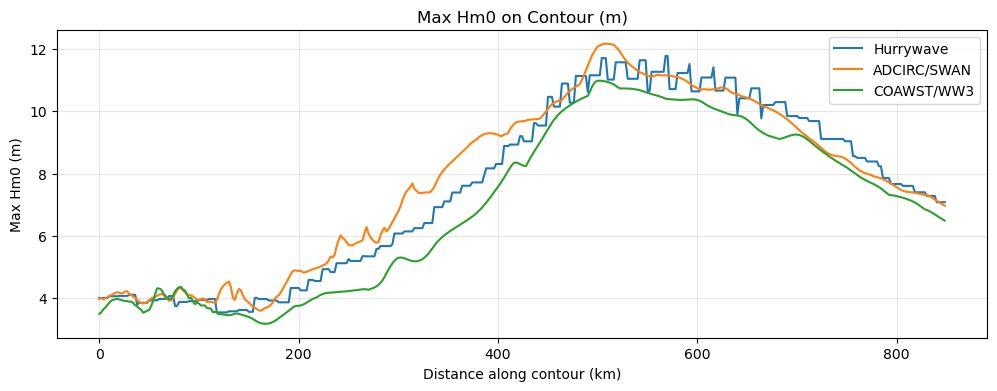

In [12]:
s = cumulative_distance(ds_hw["x"].values, ds_hw["y"].values) / 1000.0
plt.figure(figsize=(12,4))
plt.plot(s, ds_hw["hm0"].max(dim="time").values, label='Hurrywave')
plt.plot(s, ds_ad["hm0"].max(dim="time").values, label='ADCIRC/SWAN')
plt.plot(s, ds_cw["hm0"].max(dim="time").values, label='COAWST/WW3')

plt.xlabel("Distance along contour (km)")
plt.ylabel("Max Hm0 (m)")
plt.title("Max Hm0 on Contour (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('max_Hmo_on_contour.png')
plt.show()